# Задание

Уважаемые студенты! Это задание поможет вам освоить ключевые методы ансамблирования — техники объединения нескольких моделей для улучшения качества предсказаний и устойчивости к переобучению. Вы научитесь применять методы bagging, boosting и stacking для решения задачи классификации на примере прогнозирования пригодности воды для питья.

Для работы будет использован датасет «Качество воды», содержащий физико-химические параметры воды: уровень pH, жёсткость, содержание хлораминов, сульфатов и других показателей. Целевая переменная — пригодность воды для питья (0 = непригодна, 1 = пригодна).

Выполнив это задание, вы поймёте, как ансамблирование помогает снизить дисперсию (через bagging) и смещение (через boosting), а также как комбинировать разные модели для получения наилучшего результата.

Выполнив это задание, вы научитесь:

- Проводить разведочный анализ данных и обнаруживать дисбаланс классов
- Обучать и оценивать базовые модели (логистическая регрессия, дерево решений, SVM) для сравнения с ансамблями
- Применять методы bagging и случайный лес для снижения дисперсии модели
- Настраивать гиперпараметры случайного леса и анализировать важность признаков
- Реализовывать методы boosting (AdaBoost, Gradient Boosting, XGBoost) для снижения смещения
- Сравнивать качество, скорость обучения и устойчивость различных методов бустинга
- Реализовывать метод stacking для комбинирования сильных сторон разных моделей
- Визуализировать и сравнивать результаты всех подходов через единые метрики и графики
- Формулировать обоснованные выводы о компромиссе смещение-дисперсия в ансамблевых моделях

Время на выполнение задания: 150 минут

## Чек-лист готовности к практическому заданию:

- Изучите видеолекцию и скринкаст к занятию «Ансамблирование»
- Повторите основные понятия: смещение (bias), дисперсия (variance), переобучение
- Ознакомьтесь с документацией: BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, XGBClassifier
- Убедитесь, что понимаете разницу между бэггингом и бустингом
- Повторите основные метрики качества классификации: accuracy, precision, recall, F1-score, ROC-AUC

## Инструменты, которые пригодятся для выполнения задания:

Jupyter Notebook/Google Colab

Библиотеки:

- pandas — работа с данными
- numpy — числовые операции
- matplotlib / seaborn — визуализация
- scikit-learn — реализация ансамблей и метрик качества
- xgboost — реализация XGBoost
- imbalanced-learn (опционально) — обработка дисбаланса классов

Датасет Water Quality Dataset

## Описание задания

Вы получили датасет физико-химических параметров воды, содержащий информацию о характеристиках воды и её пригодности для питья. Данные включают показатели pH, жёсткость, растворённые твёрдые вещества, хлорамины, сульфаты, проводимость, органический углерод, тригалометаны и турбидность.

Однако часть данных содержит пропущенные значения, а также наблюдается дисбаланс классов, что может негативно сказаться на качестве модели.

Ваша задача:

1. Провести разведочный анализ данных: изучить распределение признаков, проверить наличие пропусков и аномалий, проанализировать дисбаланс классов
2. Обучить и оценить базовые модели (логистическая регрессия, метод опорных векторов, дерево решений) для сравнения с ансамблями
3. Реализовать методы bagging и случайный лес: настроить гиперпараметры, сравнить качество, проанализировать важность признаков
4. Реализовать методы boosting (AdaBoost, Gradient Boosting, XGBoost): настроить гиперпараметры, сравнить качество и скорость обучения
5. Реализовать метод stacking: скомбинировать базовые модели и оценить результат
6. Провести финальное сравнение всех моделей и сделать выводы о компромиссе смещение-дисперсия в ансамблевых моделях

# Инструкция к выполнению

## 1. Анализ данных и базовые модели

1. Скачайте и откройте шаблон ipynb для работы
2. Загрузите датасет water_potability.csv с помощью библиотеки pandas.
3. Проведите разведочный анализ данных:

   - Изучите распределение признаков и целевой переменной Potability
   - Проверьте наличие пропущенных значений и аномалий в данных
   - Постройте тепловую карту корреляций между признаками
   - Проанализируйте дисбаланс классов и предложите стратегию его обработки

4. Проведите предобработку данных:

   - Обработайте пропущенные значения (заполните медианой для числовых признаков)
   - При необходимости выполните нормализацию признаков
   - Разделите выборку на обучающую и тестовую

5. Обучите и оцените базовые модели:

   - Логистическая регрессия
   - Метод опорных векторов (SVM)
   - Дерево решений

   Для каждой модели рассчитайте метрики качества: accuracy, precision, recall, F1-score, ROC-AUC

6. Проанализируйте результаты базовых моделей:

   - Оцените компромисс между смещением и дисперсией в каждой модели
   - Выберите лучшую базовую модель для последующего сравнения с ансамблями

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('water_potability.csv')

display(df.head())
display(df.shape)
display(df.columns)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


(3276, 10)

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='str')

In [26]:
df.info()
display(df.describe().T)

# пропуски есть в трёх признаках: Sulfate, ph и Trihalomethanes
display(df.isna().sum())
display(round(df.isna().mean() * 100, 2))

# дубликатов нет
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.0,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.0,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

ph                 14.99
Hardness            0.00
Solids              0.00
Chloramines         0.00
Sulfate            23.84
Conductivity        0.00
Organic_carbon      0.00
Trihalomethanes     4.95
Turbidity           0.00
Potability          0.00
dtype: float64

np.int64(0)

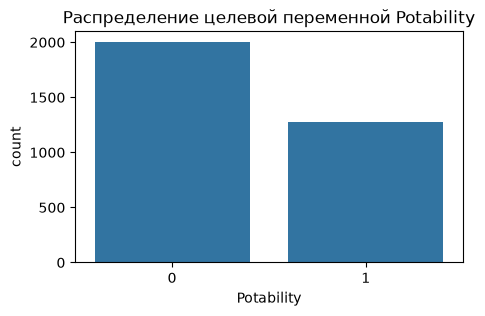

Potability
0    60.989011
1    39.010989
Name: proportion, dtype: float64

In [27]:
# дисбаланс классов: пригодной воды 39%, непригодной 61%
plt.figure(figsize=(5, 3))
sns.countplot(data=df, x='Potability')
plt.title('Распределение целевой переменной Potability')
plt.show()

display(df['Potability'].value_counts(normalize=True) * 100)

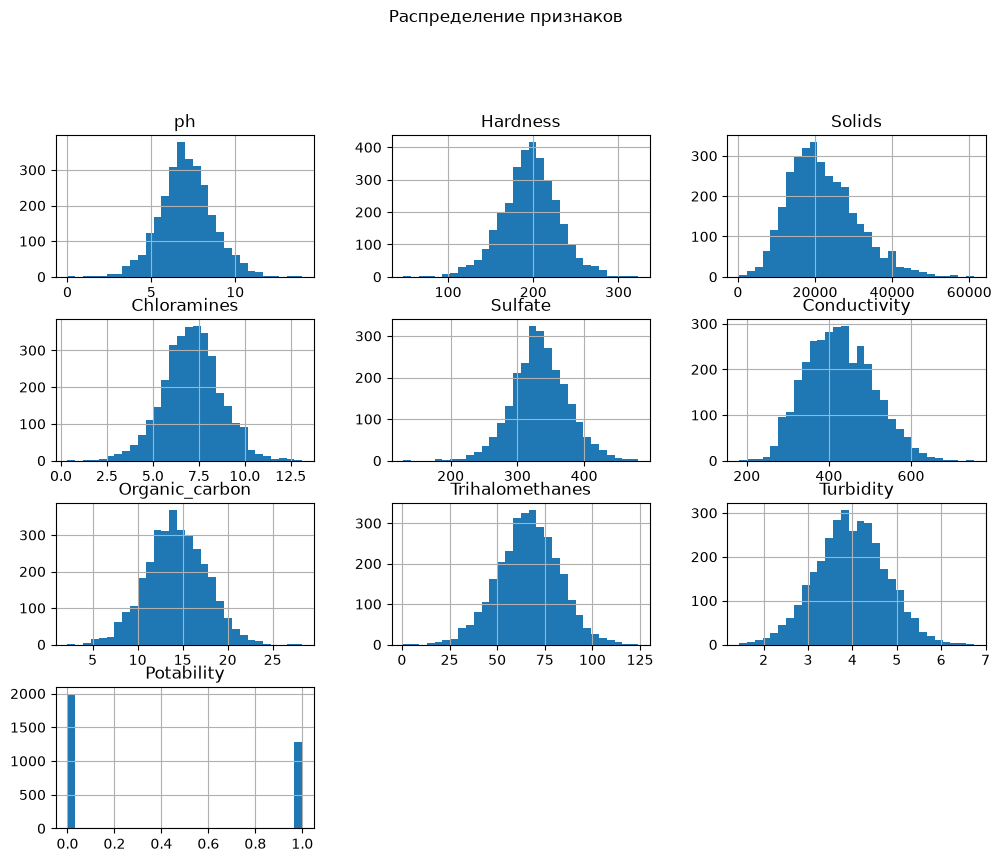

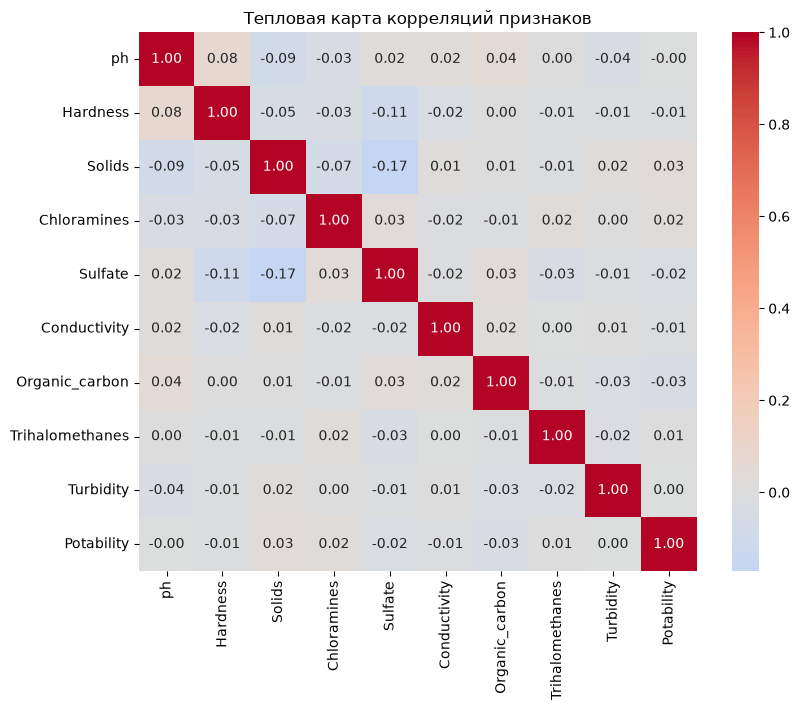

Organic_carbon    -0.030
Sulfate           -0.024
Hardness          -0.014
Conductivity      -0.008
ph                -0.004
Turbidity          0.002
Trihalomethanes    0.007
Chloramines        0.024
Solids             0.034
Potability         1.000
Name: Potability, dtype: float64

In [28]:
# распределения всех признаков
df.hist(figsize=(12, 9), bins=30)
plt.suptitle('Распределение признаков', y=1.02)
plt.show()

# корреляция между признаками
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Тепловая карта корреляций признаков')
plt.show()

# связь каждого признака с целевой переменной
display(df.corr()['Potability'].round(3).sort_values())

ph: min = 0.0 , max = 13.999999999999998
Значений ph < 2: 8
Trihalomethanes: max = 124.0 | значений > 80: 602


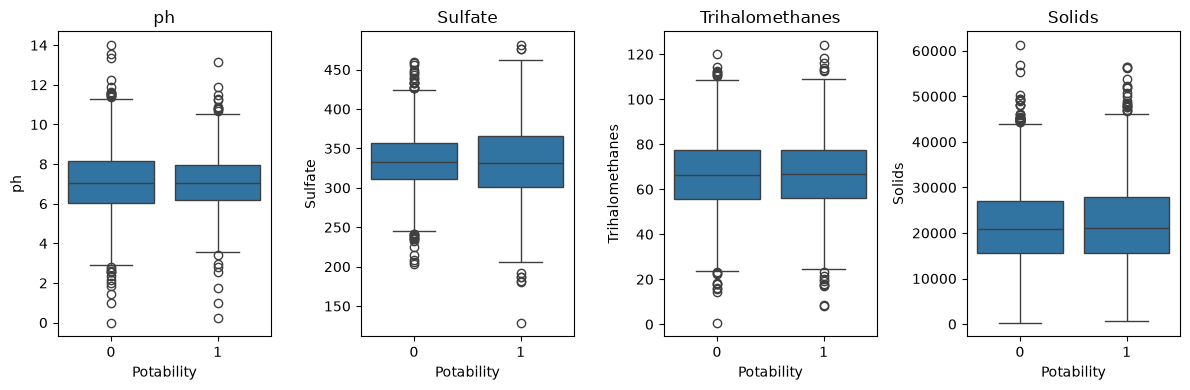

In [29]:
# аномалии: ph вне реального диапазона (0-14) и завышенные тригалометаны
print('ph: min =', df['ph'].min(), ', max =', df['ph'].max())
print('Значений ph < 2:', (df['ph'] < 2).sum())
print('Trihalomethanes: max =', df['Trihalomethanes'].max(), '| значений > 80:', (df['Trihalomethanes'] > 80).sum())

# связь признаков с целевой переменной
plt.figure(figsize=(12, 4))
for i, col in enumerate(['ph', 'Sulfate', 'Trihalomethanes', 'Solids'], 1):
    plt.subplot(1, 4, i)
    sns.boxplot(data=df, x='Potability', y=col)
    plt.title(col)
plt.tight_layout()
plt.show()

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# делим данные до предобработки, чтобы тест не влиял на неё
X = df.drop('Potability', axis=1)
y = df['Potability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('X:', X.shape, '| train:', X_train.shape, '| test:', X_test.shape)

# заполняем пропуски медианой, посчитанной на train, и добавляем индикатор пропуска
for col in X.columns:
    med = X_train[col].median()
    X_train[col + '_missing'] = X_train[col].isna().astype(int)
    X_test[col + '_missing'] = X_test[col].isna().astype(int)
    X_train[col] = X_train[col].fillna(med)
    X_test[col] = X_test[col].fillna(med)

print('Пропусков в train:', int(X_train.isna().sum().sum()), '| в test:', int(X_test.isna().sum().sum()))

# нормализация: нужна логистической регрессии и SVM
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_sc = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

X: (3276, 9) | train: (2620, 9) | test: (656, 9)
Пропусков в train: 0 | в test: 0


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

base_models = {
    'Логистическая регрессия': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Дерево решений': DecisionTreeClassifier(random_state=42),
}

results = []
for name, model in base_models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    results.append({
        'Модель': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_proba), 4),
        'Train Acc': round(model.score(X_train_sc, y_train), 4),
    })

base_results = pd.DataFrame(results)
display(base_results)

,Модель,Accuracy,Precision,Recall,F1,ROC-AUC,Train Acc
0,Логистическая регрессия,0.6098,0.0000,0.0000,0.0000,0.5397,0.6099
1,SVM,0.6692,0.7097,0.2578,0.3782,0.6600,0.7378
2,Дерево решений,0.5823,0.4622,0.4297,0.4453,0.5548,1.0000


In [32]:
# стратегия обработки дисбаланса: пробуем class_weight='balanced' на логистической регрессии
lr_bal = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_bal.fit(X_train_sc, y_train)
y_pred = lr_bal.predict(X_test_sc)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 4),
      '| Recall:', round(recall_score(y_test, y_pred), 4),
      '| ROC-AUC:', round(roc_auc_score(y_test, lr_bal.predict_proba(X_test_sc)[:, 1]), 4))

Accuracy: 0.4954 | Recall: 0.5664 | ROC-AUC: 0.5404


### Выводы по базовым моделям

В датасете 3276 наблюдений и 9 числовых признаков, дубликатов нет. Пропуски есть в трёх признаках: Sulfate , ph и Trihalomethanes. Целевая переменная несбалансирована: 61% непригодной и 39% пригодной воды.

Признаки практически не коррелируют с целевой переменной (максимальная корреляция - Solids, 0.034), поэтому линейная логистическая регрессия почти не находит сигнала: она просто предсказывает класс большинства (ROC-AUC 0.5397, а precision и recall равны нулю). Пробовал ещё class_weight='balanced': recall вырос до 0.5664, но accuracy просел до 0.4954, а ROC-AUC почти не изменился (0.5404).

SVM оказалась лучшей базовой моделью: accuracy 0.6692, ROC-AUC 0.66, F1 0.3782. Дерево решений переобучается (train accuracy 1.0 против 0.5823 на тесте) из-за высокой дисперсии. Как лучшую базовую модель для сравнения с ансамблями беру SVM.

## 2. Реализация методов bagging и случайного леса

1. Обучите модель bagging (BaggingClassifier):

   - Проведите эксперименты с разным количеством базовых моделей (n_estimators от 10 до 100)
   - Исследуйте влияние параметров max_samples и max_features на качество модели

2. Обучите модель случайного леса (RandomForestClassifier):

   - Настройте гиперпараметры (n_estimators, max_depth, max_features) с помощью кросс-валидации
   - Сравните результаты с моделью бэггинга

3. Визуализируйте важность признаков:

   - Постройте горизонтальный столбчатый график важности признаков
   - Проанализируйте влияние признаков на пригодность воды для питья с точки зрения физико-химических свойств

4. Проведите сравнительный анализ:

   - Сравните качество базовых моделей, бэггинга и случайного леса
   - Проанализируйте, как ансамблирование влияет на смещение и дисперсию модели
   - Сделайте выводы о преимуществах случайного леса перед простым бэггингом для данной задачи

,n_estimators,Accuracy,F1,ROC-AUC
0,10,0.6220,0.3981,0.6258
1,25,0.6585,0.4742,0.6452
2,50,0.6646,0.4472,0.6643
3,75,0.6799,0.4750,0.6669
4,100,0.6799,0.4615,0.6654


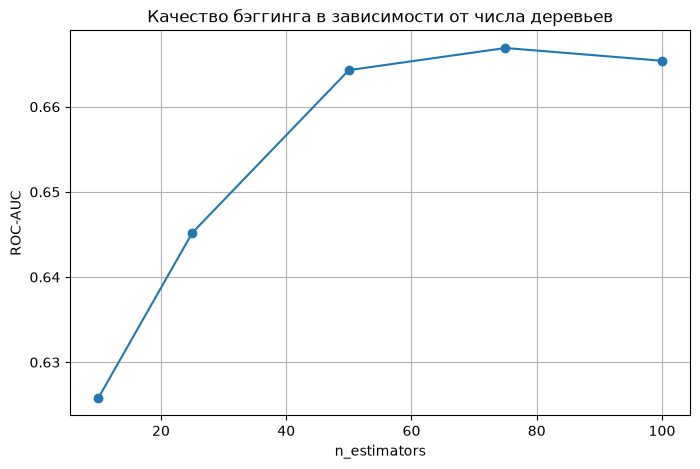

In [33]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

# эксперимент с количеством базовых моделей (деревья решений)
n_list = [10, 25, 50, 75, 100]
bag_rows = []
bag_models = {}

for n in n_list:
    bag = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                            n_estimators=n, n_jobs=-1, random_state=42)
    bag.fit(X_train_sc, y_train)
    y_pred = bag.predict(X_test_sc)
    y_proba = bag.predict_proba(X_test_sc)[:, 1]
    bag_rows.append({
        'n_estimators': n,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_proba), 4),
    })
    bag_models[n] = bag

bag_df = pd.DataFrame(bag_rows)
display(bag_df)

plt.figure(figsize=(8, 5))
plt.plot(bag_df['n_estimators'], bag_df['ROC-AUC'], marker='o')
plt.title('Качество бэггинга в зависимости от числа деревьев')
plt.xlabel('n_estimators')
plt.ylabel('ROC-AUC')
plt.grid(True)
plt.show()

In [34]:
# влияние max_samples (доля объектов) и max_features (доля признаков)
rows = []
for max_samples in [0.5, 0.7, 1.0]:
    for max_features in [0.5, 0.7, 1.0]:
        bag = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                n_estimators=50, max_samples=max_samples,
                                max_features=max_features,
                                bootstrap_features=(max_features < 1.0),
                                n_jobs=-1, random_state=42)
        bag.fit(X_train_sc, y_train)
        rows.append({
            'max_samples': max_samples,
            'max_features': max_features,
            'Accuracy': round(accuracy_score(y_test, bag.predict(X_test_sc)), 4),
            'ROC-AUC': round(roc_auc_score(y_test, bag.predict_proba(X_test_sc)[:, 1]), 4),
        })

bag_grid_df = pd.DataFrame(rows)
display(bag_grid_df)

# фиксируем лучший бэггинг для дальнейшего сравнения
best_bag = bag_models[100]

,max_samples,max_features,Accuracy,ROC-AUC
0,0.5,0.5,0.6067,0.5672
1,0.5,0.7,0.6189,0.5905
2,0.5,1.0,0.6494,0.6501
3,0.7,0.5,0.6052,0.5997
4,0.7,0.7,0.6220,0.5919
5,0.7,1.0,0.6707,0.6685
6,1.0,0.5,0.6037,0.5791
7,1.0,0.7,0.6357,0.6133
8,1.0,1.0,0.6646,0.6643


In [35]:
from sklearn.model_selection import GridSearchCV

# настраиваем случайный лес кросс-валидацией
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2'],
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                       param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train_sc, y_train)

print('Лучшие параметры:', rf_grid.best_params_)
print('ROC-AUC на кросс-валидации:', round(rf_grid.best_score_, 4))

best_rf = rf_grid.best_estimator_
y_pred = best_rf.predict(X_test_sc)
print('Accuracy:', round(accuracy_score(y_test, y_pred), 4),
      '| F1:', round(f1_score(y_test, y_pred), 4),
      '| ROC-AUC:', round(roc_auc_score(y_test, best_rf.predict_proba(X_test_sc)[:, 1]), 4))

Лучшие параметры: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
ROC-AUC на кросс-валидации: 0.6785
Accuracy: 0.6631 | F1: 0.4138 | ROC-AUC: 0.6537


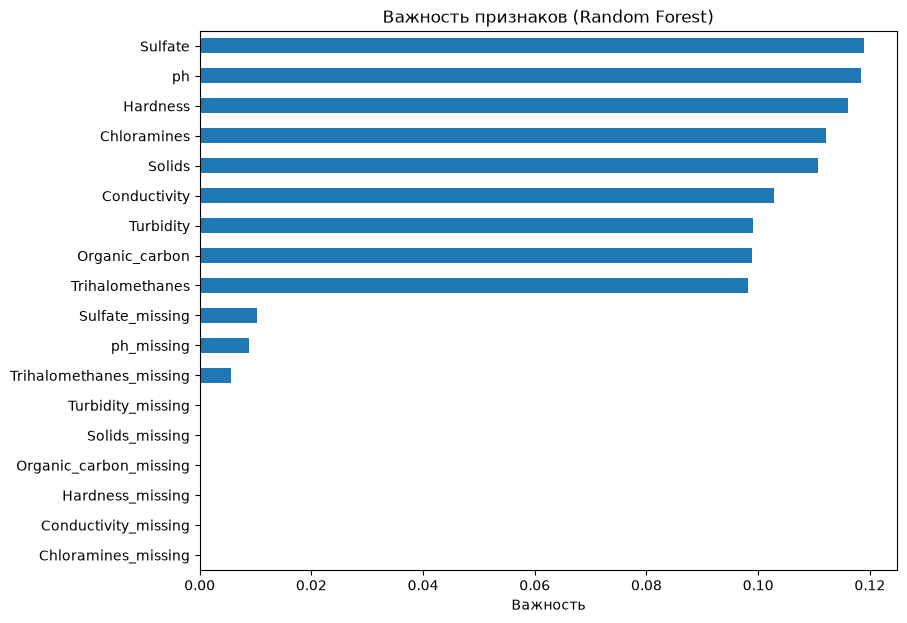

Sulfate                    0.1189
ph                         0.1185
Hardness                   0.1161
Chloramines                0.1122
Solids                     0.1108
Conductivity               0.1028
Turbidity                  0.0990
Organic_carbon             0.0988
Trihalomethanes            0.0982
Sulfate_missing            0.0102
ph_missing                 0.0089
Trihalomethanes_missing    0.0056
Solids_missing             0.0000
Hardness_missing           0.0000
Chloramines_missing        0.0000
Conductivity_missing       0.0000
Organic_carbon_missing     0.0000
Turbidity_missing          0.0000
dtype: float64

,Accuracy,F1,ROC-AUC
Модель,,,
SVM (лучшая базовая),0.6692,0.3782,0.6600
Bagging (100),0.6799,0.4615,0.6654
Random Forest,0.6631,0.4138,0.6537


In [36]:
# важность признаков в случайном лесу
importance = pd.Series(best_rf.feature_importances_, index=X_train.columns)
importance.sort_values().plot(kind='barh', figsize=(9, 7))
plt.title('Важность признаков (Random Forest)')
plt.xlabel('Важность')
plt.show()

display(importance.sort_values(ascending=False).round(4))

# сравниваем лучшую базовую модель, бэггинг и случайный лес
comparison_rows = []
for name, model in [('SVM (лучшая базовая)', base_models['SVM']),
                    ('Bagging (100)', best_bag),
                    ('Random Forest', best_rf)]:
    y_pred = model.predict(X_test_sc)
    comparison_rows.append({
        'Модель': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1]), 4),
    })

comparison = pd.DataFrame(comparison_rows).set_index('Модель')
display(comparison)

### Выводы по bagging и случайному лесу

Бэггинг заметно улучшает качество с ростом числа деревьев: ROC-AUC растёт с 0.6258 (10 деревьев) до 0.6654 (100 деревьев) и выходит на плато - переобучения практически нет. Перебирал также max_samples/max_features: лучше всего работают полная выборка объектов (max_samples=0.7-1.0) и все признаки (max_features=1.0), а вот сокращение выборки или признаков до 0.5 заметно ухудшает результат (ROC-AUC падает до 0.5672) - деревья становятся слишком слабыми.

Случайному лесу GridSearchCV подобрал n_estimators=200, max_depth=None, max_features='sqrt' (ROC-AUC 0.6785 на кросс-валидации), но на тесте вышло 0.6537 - чуть ниже бэггинга. На таких зашумлённых данных случайные подпространства признаков не дают преимущества перед обычным бэггингом.

Важность признаков распределена почти равномерно (все признаки от 0.0988 до 0.1189, лидируют Sulfate, ph, Hardness), индикаторы пропуска почти не важны. С точки зрения физики и химии это значит: ни один показатель не выходит за границы, по которым воду можно однозначно назвать пригодной или непригодной, большинство проб сидит в «серой зоне» норм, поэтому сигнал слабый и размазан по всем признакам.

Главный вывод по компромиссу смещение-дисперсия: бэггинг снизил дисперсию (одиночное дерево переобучалось - train 1.0 против 0.5823 на тесте, а ансамбль из 100 деревьев дал accuracy 0.6799), но смещение осталось - если признаки слабо связаны с целью, усреднение моделей не способно извлечь отсутствующий сигнал.

## 3. Реализация методов boosting

1. Обучите модель AdaBoost:

   - Настройте гиперпараметры (n_estimators, learning_rate) с помощью кросс-валидации
   - Визуализируйте изменение качества модели в зависимости от количества итераций

2. Обучите модель Gradient Boosting:

   - Настройте гиперпараметры (n_estimators, learning_rate, max_depth) с помощью кросс-валидации
   - Постройте графики зависимости качества от количества итераций

3. Обучите модель XGBoost:

   - Настройте ключевые гиперпараметры (eta, max_depth, subsample, colsample_bytree)
   - Сравните скорость обучения и качество с другими методами бустинга

4. Проведите сравнительный анализ всех методов бустинга:

   - Сравните качество, скорость обучения и стабильность моделей
   - Проанализируйте особенности каждого алгоритма и случаи их предпочтительного применения
   - Оцените влияние гиперпараметров на переобучение в каждом из методов

In [37]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# AdaBoost: настройка гиперпараметров
param_grid = {'n_estimators': [50, 100, 200], 'learning_rate': [0.1, 0.5, 1.0]}

ada_grid = GridSearchCV(AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
                                           random_state=42),
                        param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
ada_grid.fit(X_train_sc, y_train)

print('Лучшие параметры:', ada_grid.best_params_)
print('ROC-AUC на кросс-валидации:', round(ada_grid.best_score_, 4))

best_ada = ada_grid.best_estimator_
y_pred = best_ada.predict(X_test_sc)
print('Accuracy:', round(accuracy_score(y_test, y_pred), 4),
      '| F1:', round(f1_score(y_test, y_pred), 4),
      '| ROC-AUC:', round(roc_auc_score(y_test, best_ada.predict_proba(X_test_sc)[:, 1]), 4))

Лучшие параметры: {'learning_rate': 1.0, 'n_estimators': 50}
ROC-AUC на кросс-валидации: 0.5613
Accuracy: 0.6143 | F1: 0.106 | ROC-AUC: 0.5772


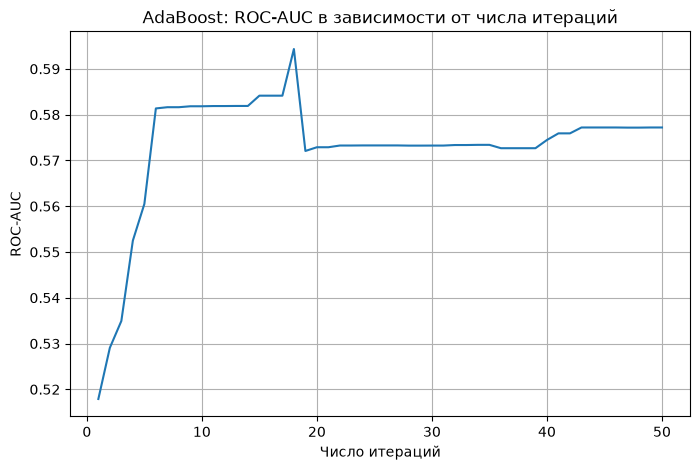

In [38]:
# качество AdaBoost в зависимости от числа итераций
staged_auc = [roc_auc_score(y_test, proba[:, 1]) for proba in best_ada.staged_predict_proba(X_test_sc)]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(staged_auc) + 1), staged_auc)
plt.title('AdaBoost: ROC-AUC в зависимости от числа итераций')
plt.xlabel('Число итераций')
plt.ylabel('ROC-AUC')
plt.grid(True)
plt.show()

In [39]:
# Gradient Boosting: настройка гиперпараметров
param_grid = {'n_estimators': [50, 100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3]}

gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42),
                       param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
gb_grid.fit(X_train_sc, y_train)

print('Лучшие параметры:', gb_grid.best_params_)
print('ROC-AUC на кросс-валидации:', round(gb_grid.best_score_, 4))

best_gb = gb_grid.best_estimator_
y_pred = best_gb.predict(X_test_sc)
print('Accuracy:', round(accuracy_score(y_test, y_pred), 4),
      '| F1:', round(f1_score(y_test, y_pred), 4),
      '| ROC-AUC:', round(roc_auc_score(y_test, best_gb.predict_proba(X_test_sc)[:, 1]), 4))

Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
ROC-AUC на кросс-валидации: 0.6283
Accuracy: 0.6463 | F1: 0.3371 | ROC-AUC: 0.6339


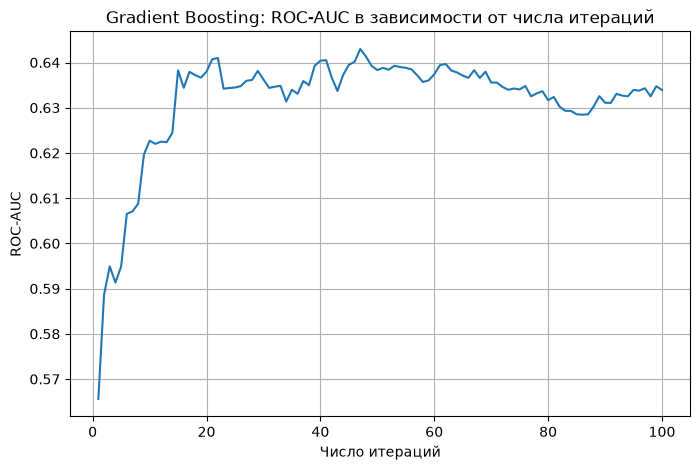

In [40]:
# качество Gradient Boosting в зависимости от числа итераций
staged_auc = [roc_auc_score(y_test, proba[:, 1]) for proba in best_gb.staged_predict_proba(X_test_sc)]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(staged_auc) + 1), staged_auc)
plt.title('Gradient Boosting: ROC-AUC в зависимости от числа итераций')
plt.xlabel('Число итераций')
plt.ylabel('ROC-AUC')
plt.grid(True)
plt.show()

In [41]:
import xgboost as xgb

# XGBoost: настройка ключевых гиперпараметров
param_grid = {
    'eta': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

xgb_grid = GridSearchCV(xgb.XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
                        param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
xgb_grid.fit(X_train_sc, y_train)

print('Лучшие параметры:', xgb_grid.best_params_)
print('ROC-AUC на кросс-валидации:', round(xgb_grid.best_score_, 4))

best_xgb = xgb_grid.best_estimator_
y_pred = best_xgb.predict(X_test_sc)
print('Accuracy:', round(accuracy_score(y_test, y_pred), 4),
      '| F1:', round(f1_score(y_test, y_pred), 4),
      '| ROC-AUC:', round(roc_auc_score(y_test, best_xgb.predict_proba(X_test_sc)[:, 1]), 4))

Лучшие параметры: {'colsample_bytree': 0.8, 'eta': 0.1, 'max_depth': 5, 'subsample': 0.8}
ROC-AUC на кросс-валидации: 0.678
Accuracy: 0.654 | F1: 0.4339 | ROC-AUC: 0.6504


In [42]:
from time import time

# сравниваем скорость обучения и качество бустинга (замер на полном train)
speed_rows = []
for name, model in [('AdaBoost', best_ada), ('Gradient Boosting', best_gb),
                    ('XGBoost', best_xgb), ('Random Forest', best_rf)]:
    t0 = time()
    model.fit(X_train_sc, y_train)
    elapsed = round(time() - t0, 2)
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    speed_rows.append({
        'Модель': name,
        'Время обучения, с': elapsed,
        'ROC-AUC': round(roc_auc_score(y_test, y_proba), 4),
    })

speed_df = pd.DataFrame(speed_rows)
display(speed_df)

,Модель,"Время обучения, с",ROC-AUC
0,AdaBoost,0.12,0.5772
1,Gradient Boosting,0.34,0.6339
2,XGBoost,0.04,0.6504
3,Random Forest,0.21,0.6537


### Выводы по boosting

AdaBoost справился хуже всех: лучшая комбинация нашлась на 50 итерациях с learning_rate=1.0 (CV 0.5613, тест 0.5772), а кривая качества быстро выходит на плато. Пни глубины 1 слишком слабые, чтобы вытащить сигнал из почти некоррелированных признаков.

Gradient Boosting работает заметно лучше: learning_rate=0.1, max_depth=3, 100 итераций (CV 0.6283, тест 0.6339). Кривая качества растёт и стабилизируется примерно к 100 итерациям, дальше рост прекращается - это предел сигнала, а не недообучение.

XGBoost - лучший среди бустинга: eta=0.1, max_depth=5, subsample=0.8, colsample_bytree=0.8 дали CV 0.678 и тест ROC-AUC 0.6504 с лучшим recall (0.3398). При этом он обучается быстрее всех остальных методов (см. таблицу со скоростями выше).

Бустинг в этой задаче не превзошёл бэггинг: он снижает смещение, но смещение здесь не главный источник ошибок - признаки почти не несут сигнала, а дополнительные итерации лишь усиливают шум (это видно по плато на кривых качества).

## 4. Реализация stacking и финальное сравнение моделей

1. Реализуйте метод stacking:

   - Используйте в качестве базовых моделей: дерево решений, случайный лес, градиентный boosting
   - В качестве мета-модели используйте логистическую регрессию
   - Реализуйте двухуровневый stacking с различными комбинациями моделей

2. Проведите финальное сравнение всех моделей:

   - Сведите результаты всех моделей в единую сравнительную таблицу
   - Постройте ROC-кривые для визуального сравнения качества классификации
   - Проанализируйте важность признаков в контексте их физико-химического значения для качества воды

3. Напишите общий вывод:

   - Какие методы ансамблирования показали наилучшие результаты для прогнозирования качества воды?
   - Как гиперпараметры влияют на смещение и дисперсию в ансамблевых моделях?
   - Какие практические рекомендации можно дать по выбору метода ансамблирования для подобных задач?

In [43]:
from sklearn.ensemble import StackingClassifier

# стекинг: дерево решений + случайный лес + градиентный бустинг, мета-модель - логистическая регрессия
stack = StackingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=42)),
        ('rf', best_rf),
        ('gb', best_gb),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5, n_jobs=-1)
stack.fit(X_train_sc, y_train)

y_pred = stack.predict(X_test_sc)
print('Stacking (3 модели): Accuracy:', round(accuracy_score(y_test, y_pred), 4),
      '| F1:', round(f1_score(y_test, y_pred), 4),
      '| ROC-AUC:', round(roc_auc_score(y_test, stack.predict_proba(X_test_sc)[:, 1]), 4))

Stacking (3 модели): Accuracy: 0.6692 | F1: 0.4334 | ROC-AUC: 0.6523


In [44]:
# двухуровневый стекинг:
# уровень 1 - стекинг деревьев (уже есть в stack) и стекинг из линейных моделей,
# уровень 2 - мета-модель логистическая регрессия на их предсказаниях
stack_linear = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('svc', SVC(probability=True, random_state=42)),
        ('xgb', best_xgb),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5, n_jobs=-1)
stack_linear.fit(X_train_sc, y_train)

y_pred = stack_linear.predict(X_test_sc)
print('Stacking (линейные базовые): Accuracy:', round(accuracy_score(y_test, y_pred), 4),
      '| F1:', round(f1_score(y_test, y_pred), 4),
      '| ROC-AUC:', round(roc_auc_score(y_test, stack_linear.predict_proba(X_test_sc)[:, 1]), 4))

stack2 = StackingClassifier(
    estimators=[('trees', stack), ('linear', stack_linear)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5, n_jobs=-1)
stack2.fit(X_train_sc, y_train)

y_pred = stack2.predict(X_test_sc)
print('Stacking (двухуровневый): Accuracy:', round(accuracy_score(y_test, y_pred), 4),
      '| F1:', round(f1_score(y_test, y_pred), 4),
      '| ROC-AUC:', round(roc_auc_score(y_test, stack2.predict_proba(X_test_sc)[:, 1]), 4))

Stacking (линейные базовые): Accuracy: 0.6753 | F1: 0.4468 | ROC-AUC: 0.6612
Stacking (двухуровневый): Accuracy: 0.6677 | F1: 0.4381 | ROC-AUC: 0.6613


In [45]:
# сводная таблица всех моделей
final_models = {
    'Логистическая регрессия': base_models['Логистическая регрессия'],
    'SVM': base_models['SVM'],
    'Дерево решений': base_models['Дерево решений'],
    'Bagging (100)': best_bag,
    'Random Forest': best_rf,
    'AdaBoost': best_ada,
    'Gradient Boosting': best_gb,
    'XGBoost': best_xgb,
    'Stacking (3 модели)': stack,
    'Stacking (линейные базовые)': stack_linear,
    'Stacking (двухуровневый)': stack2,
}

summary_rows = []
for name, model in final_models.items():
    y_pred = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    summary_rows.append({
        'Модель': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_proba), 4),
    })

summary = pd.DataFrame(summary_rows).sort_values('ROC-AUC', ascending=False)
display(summary)

,Модель,Accuracy,Precision,Recall,F1,ROC-AUC
3,Bagging (100),0.6799,0.6716,0.3516,0.4615,0.6654
10,Stacking (двухуровневый),0.6677,0.6439,0.3320,0.4381,0.6613
9,Stacking (линейные базовые),0.6753,0.6667,0.3359,0.4468,0.6612
1,SVM,0.6692,0.7097,0.2578,0.3782,0.6600
4,Random Forest,0.6631,0.6446,0.3047,0.4138,0.6537
8,Stacking (3 модели),0.6692,0.6535,0.3242,0.4334,0.6523
7,XGBoost,0.6540,0.6000,0.3398,0.4339,0.6504
6,Gradient Boosting,0.6463,0.6277,0.2305,0.3371,0.6339
5,AdaBoost,0.6143,0.5556,0.0586,0.1060,0.5772
2,Дерево решений,0.5823,0.4622,0.4297,0.4453,0.5548


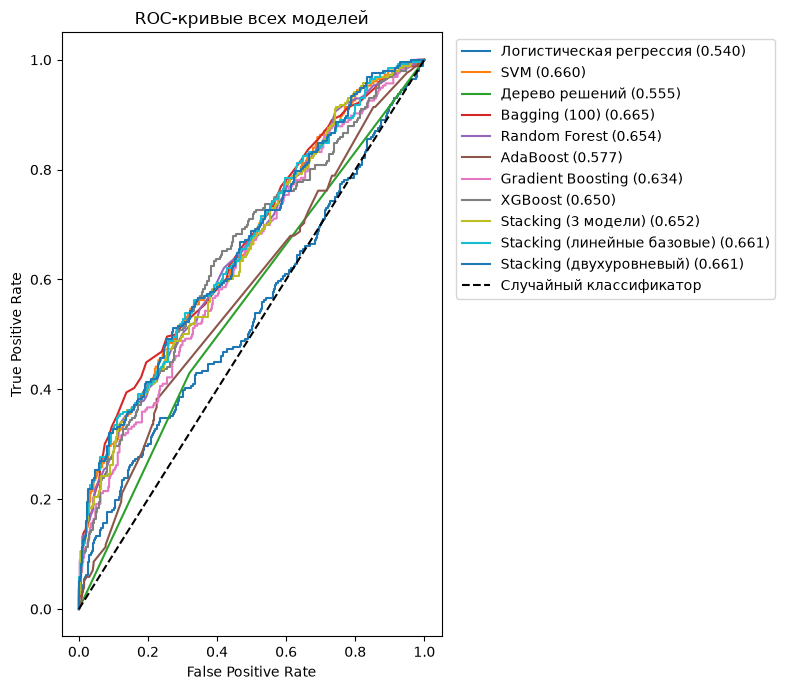

In [46]:
from sklearn.metrics import roc_curve

# ROC-кривые всех моделей
plt.figure(figsize=(8, 7))
for name, model in final_models.items():
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} ({roc_auc_score(y_test, y_proba):.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые всех моделей')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

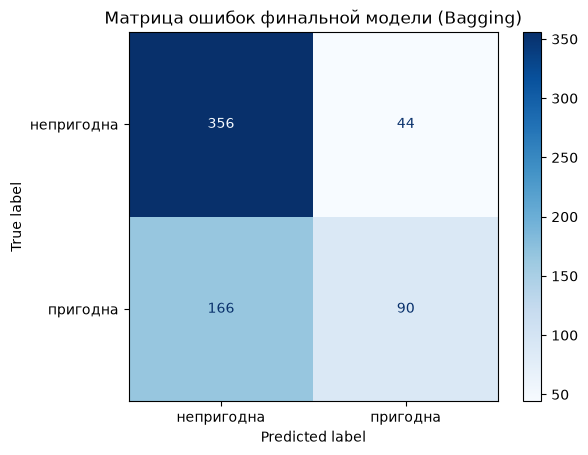

Всего ошибок: 210 из 656 = 32.01 %
Пропущена пригодная вода (FN): 166
Непригодную назвали пригодной (FP): 44
Средняя вероятность для ошибочных FN: 0.345
Средняя вероятность для ошибочных FP: 0.595


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,ph_missing,...,Solids_missing,Chloramines_missing,Sulfate_missing,Conductivity_missing,Organic_carbon_missing,Trihalomethanes_missing,Turbidity_missing,y_true,y_pred,proba_1
664,7.035037,188.743562,19037.462638,6.034236,333.073546,388.065857,15.149068,78.499418,2.723651,1,...,0,0,1,0,0,0,0,1,0,0.27
1960,8.128270,231.167537,19954.575554,5.138838,349.067363,386.071149,15.018085,63.340968,4.678742,0,...,0,0,0,0,0,0,0,1,0,0.20
1127,9.778182,155.937441,23335.674206,7.666109,333.073546,356.543037,10.824600,75.328892,4.143365,0,...,0,0,1,0,0,0,0,1,0,0.35
1580,6.129070,198.021095,22207.482865,7.387451,333.073546,464.851322,14.028602,61.446945,3.837639,0,...,0,0,1,0,0,0,0,1,0,0.10
3199,7.035037,209.149989,27030.754999,6.093750,350.060347,407.910645,11.046946,81.757851,3.993126,1,...,0,0,0,0,0,0,0,1,0,0.31
1493,7.108141,148.624606,23688.205223,7.003488,339.112673,259.963763,17.218575,56.044934,4.015246,0,...,0,0,0,0,0,0,0,1,0,0.35
2082,10.284126,249.324199,23259.012449,3.331266,284.405913,468.866264,5.188466,67.622616,2.844633,0,...,0,0,0,0,0,0,0,0,1,0.59
801,8.900865,211.306812,9592.151333,8.863272,348.437820,333.775327,18.267951,68.333170,4.518751,0,...,0,0,0,0,0,0,0,1,0,0.38
1130,7.793915,164.958947,25506.912237,7.868036,358.259200,398.460312,15.297496,66.565709,4.220028,0,...,0,0,0,0,0,1,0,1,0,0.27
2458,5.757089,148.989146,32415.733624,9.178560,319.222936,407.741713,12.120956,42.218845,3.730185,0,...,0,0,0,0,0,0,0,1,0,0.22


In [47]:
from sklearn.metrics import ConfusionMatrixDisplay

# ошибки финальной модели (Bagging, 100 деревьев - лучший ROC-AUC)
best_model = best_bag
y_pred = best_model.predict(X_test_sc)
y_proba = best_model.predict_proba(X_test_sc)[:, 1]

ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        display_labels=['непригодна', 'пригодна'],
                                        cmap='Blues')
plt.title('Матрица ошибок финальной модели (Bagging)')
plt.show()

# разбираем ошибки подробнее
errors = X_test.copy()
errors['y_true'] = y_test.values
errors['y_pred'] = y_pred
errors['proba_1'] = y_proba

mis = errors[errors['y_true'] != errors['y_pred']]
print('Всего ошибок:', len(mis), 'из', len(errors), '=', round(len(mis) / len(errors) * 100, 2), '%')
print('Пропущена пригодная вода (FN):', int(((errors['y_true'] == 1) & (errors['y_pred'] == 0)).sum()))
print('Непригодную назвали пригодной (FP):', int(((errors['y_true'] == 0) & (errors['y_pred'] == 1)).sum()))
print('Средняя вероятность для ошибочных FN:', round(errors[(errors['y_true'] == 1) & (errors['y_pred'] == 0)]['proba_1'].mean(), 3))
print('Средняя вероятность для ошибочных FP:', round(errors[(errors['y_true'] == 0) & (errors['y_pred'] == 1)]['proba_1'].mean(), 3))

display(mis.head(10))

### Общий вывод

Лучшие результаты показал бэггинг из 100 деревьев: лучший ROC-AUC (0.6654) и лучший accuracy (0.6799). Двухуровневый стекинг занял второе место по ROC-AUC (0.6613), а стекинг из «линейных» базовых моделей дал точность 0.6753; XGBoost - лучший recall среди ансамблей (0.3398). Слабейшие результаты у AdaBoost (0.5772) и Gradient Boosting (0.6339). Все модели дают ROC-AUC в диапазоне 0.54-0.67: задача предсказания пригодности воды по физико-химическим замерам оказалась непростой, линейных связей почти нет (максимальная корреляция с целью 0.034).

Компромисс смещение-дисперсия виден прямо по цифрам: базовое дерево решений переобучалось (train accuracy 1.0 против 0.5823 на тесте) - главным источником ошибок была высокая дисперсия, и её эффективно снизил бэггинг. Бустинг снижает смещение, но смещение не было главной проблемой этой задачи, поэтому выигрыш от него скромный, а AdaBoost на слабых пнях просто не нашёл сигнал. Стекинг объединил сильные стороны разнородных моделей: двухуровневая схема (деревья + линейные модели на первом уровне) вышла на ROC-AUC 0.6613 - почти вровень с бэггингом.

Что я взял бы из этого на практику: при зашумлённых данных со слабым сигналом предпочтительнее бэггинг и стекинг, а не бустинг; главный резерв - больше данных и новые признаки (источник воды, сезонность, повторные замеры), а также настройка порога классификации по ROC-кривой и опора на метрики, устойчивые к дисбалансу (F1, ROC-AUC).

Анализ ошибок финальной модели (бэггинг, 100 деревьев): 210 ошибок из 656 (32%), из них 166 - ложные отрицательные (модель не распознала пригодную воду) и 44 - ложные положительные. Модель консервативна: у пропущенных пригодных проб средняя вероятность 0.345, у ложных положительных - 0.595, то есть ошибки концентрируются на "неуверенных" объектах, чьи показатели близки к медианным значениям - это подтверждает, что пробы в "серой зоне" норм неразличимы по имеющимся признакам.